# Model Analysis

In this notebook we will first explore the dataset used to train the model to then analyse the robustness of this model against typical attacks. We will explore whether or not the use of uncertainty can make the model aware of slight changes in the input.

## Import libraries

In [8]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from collections import defaultdict

In [45]:
import pandas as pd
import re
import random

In [46]:
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [9]:
from src.data import load_and_prepare_datasets
from src.utils import load_model
from src.gaussian_processes.prediction import predict_with_uncertainty

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
model, tokenizer = load_model("models/gp_best", device=device)
model.eval()

[INFO] Loading model from: models/gp_best


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


models/gp_best\pytorch_model.bin
[INFO] Model loaded successfully.


DistilBERTWithGP(
  (encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Li

## Data exploration

First, we will load the complete dataset

In [13]:
datasets, id2label = load_and_prepare_datasets(
    tokenizer=tokenizer,
)
 
test_set = datasets["test"]
print("Lenght of the test set:", len(test_set))

Jigsaw dataset already exists. Skipping download.


Map:   0%|          | 0/129251 [00:00<?, ? examples/s]

Map:   0%|          | 0/14362 [00:00<?, ? examples/s]

Map:   0%|          | 0/15958 [00:00<?, ? examples/s]

Lenght of the test set: 15958


In [14]:
i = 4
sample = test_set[i]
 
text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
label = sample["labels"]

print("======== EXAMPLE =========")
 
print("TEXT:", text)
print("TRUE LABELS:", label.numpy())
print("CLASS NAMES:", id2label)

print("\n MODEL PREDICTIONS:")

result = predict_with_uncertainty(model, tokenizer, text, id2label, device="cuda")
for label, prob, std in result["all_scores"]:
        print(f"{label:15s} | prob={prob:.4f} | std={std:.4f}")

print("=========================")

======== EXAMPLE =========
TEXT: fuck you wanker
TRUE LABELS: [1. 1. 1. 0. 1. 0.]
CLASS NAMES: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

 MODEL PREDICTIONS:
toxic           | prob=0.9948 | std=0.0717
severe_toxic    | prob=0.4348 | std=0.4957
obscene         | prob=0.9919 | std=0.0895
threat          | prob=0.0080 | std=0.0890
insult          | prob=0.8691 | std=0.3373
identity_hate   | prob=0.1451 | std=0.3522


Now, we will see the class distribution in the dataset

=== Missing values ===
No missing values

=== Class distributions (N=159,571) ===
  toxic          : 15,294  (9.58%)
  severe_toxic   :  1,595  (1.00%)
  obscene        :  8,449  (5.29%)
  threat         :    478  (0.30%)
  insult         :  7,877  (4.94%)
  identity_hate  :  1,405  (0.88%)


C:\Users\User\AppData\Local\Temp\ipykernel_47120\3227809526.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


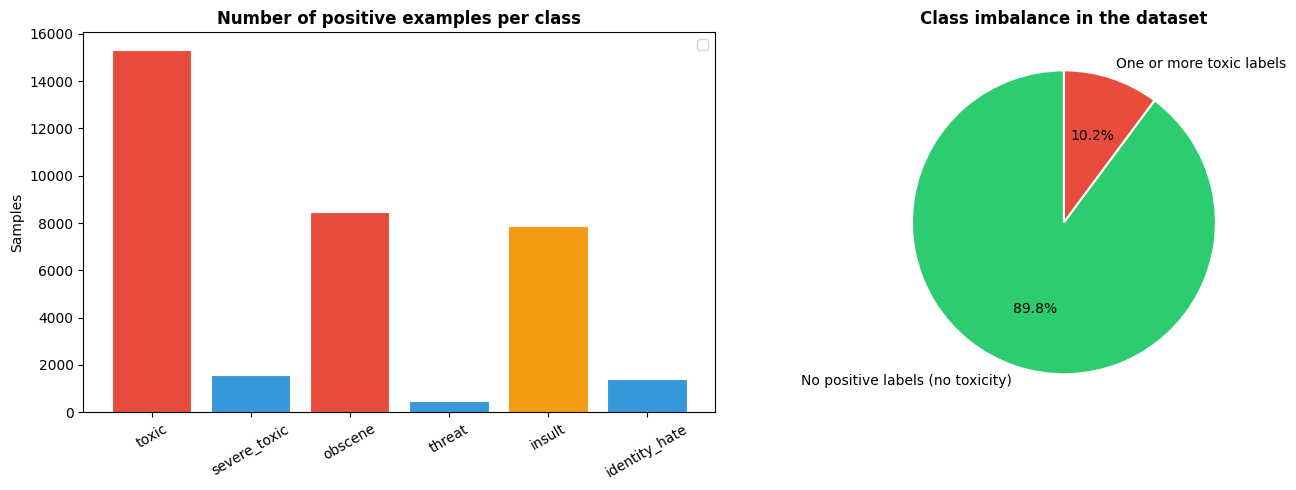

In [28]:
# Load the train set
df_raw = pd.read_csv('data/jigsaw/train.csv')

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Missing values
print('=== Missing values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')

# --- Class distribution ---
counts = df_raw[label_cols].sum()
total = len(df_raw)
print(f'\n=== Class distributions (N={total:,}) ===')
for col in label_cols:
    n = int(counts[col])
    pct = 100 * n / total
    print(f'  {col:15s}: {n:6,}  ({pct:.2f}%)')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart – counter
colors = ['#e74c3c' if c > 0.05 * total else '#f39c12' if c > 0.01 * total else '#3498db'
          for c in counts]
axes[0].bar(label_cols, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Number of positive examples per class', fontweight='bold')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Pie – positive vs at least one negative
any_toxic = (df_raw[label_cols].sum(axis=1) > 0).sum()
clean = total - any_toxic
axes[1].pie(
    [clean, any_toxic],
    labels=['No positive labels (no toxicity)', 'One or more toxic labels'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Class imbalance in the dataset', fontweight='bold')

plt.tight_layout()
plt.show()

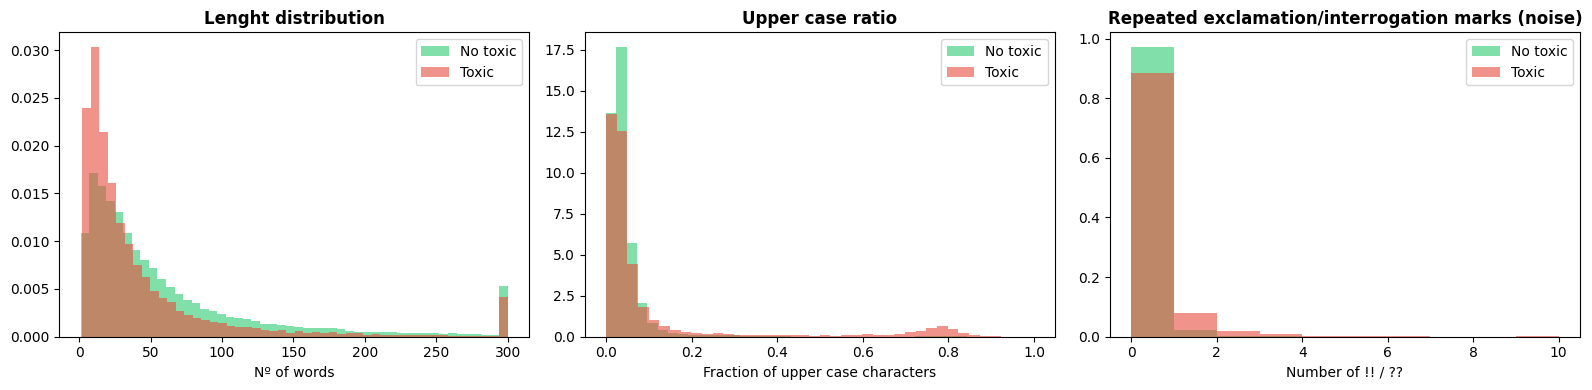

Lenght stadistics:
               mean   50%     max
toxic                            
No toxic  68.967874  38.0  1250.0
Toxic     51.289787  22.0  1411.0


In [30]:
### Analysis on text lenghts and noise

df_raw['n_words'] = df_raw['comment_text'].str.split().str.len()
df_raw['n_chars'] = df_raw['comment_text'].str.len()
df_raw['n_caps_ratio'] = df_raw['comment_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
df_raw['n_punct'] = df_raw['comment_text'].apply(
    lambda x: len(re.findall(r'[!?]{2,}', str(x)))
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de longitud en palabras (por clase)
toxic_mask = df_raw['toxic'] == 1
axes[0].hist(df_raw.loc[~toxic_mask, 'n_words'].clip(upper=300), bins=50,
             alpha=0.6, label='No toxic', color='#2ecc71', density=True)
axes[0].hist(df_raw.loc[toxic_mask, 'n_words'].clip(upper=300), bins=50,
             alpha=0.6, label='Toxic', color='#e74c3c', density=True)
axes[0].set_title('Lenght distribution', fontweight='bold')
axes[0].set_xlabel('Nº of words')
axes[0].legend()

# Ratio de mayúsculas
axes[1].hist(df_raw.loc[~toxic_mask, 'n_caps_ratio'], bins=40,
             alpha=0.6, label='No toxic', color='#2ecc71', density=True)
axes[1].hist(df_raw.loc[toxic_mask, 'n_caps_ratio'], bins=40,
             alpha=0.6, label='Toxic', color='#e74c3c', density=True)
axes[1].set_title('Upper case ratio', fontweight='bold')
axes[1].set_xlabel('Fraction of upper case characters')
axes[1].legend()

# Signos de puntuación repetidos
axes[2].hist(df_raw.loc[~toxic_mask, 'n_punct'].clip(upper=10), bins=10,
             alpha=0.6, label='No toxic', color='#2ecc71', density=True)
axes[2].hist(df_raw.loc[toxic_mask, 'n_punct'].clip(upper=10), bins=10,
             alpha=0.6, label='Toxic', color='#e74c3c', density=True)
axes[2].set_title('Repeated exclamation/interrogation marks (noise)', fontweight='bold')
axes[2].set_xlabel('Number of !! / ??')
axes[2].legend()

plt.tight_layout()
plt.show()

print('Lenght stadistics:')
print(df_raw.groupby('toxic')['n_words'].describe()[['mean','50%','max']].rename(index={0:'No toxic',1:'Toxic'}))

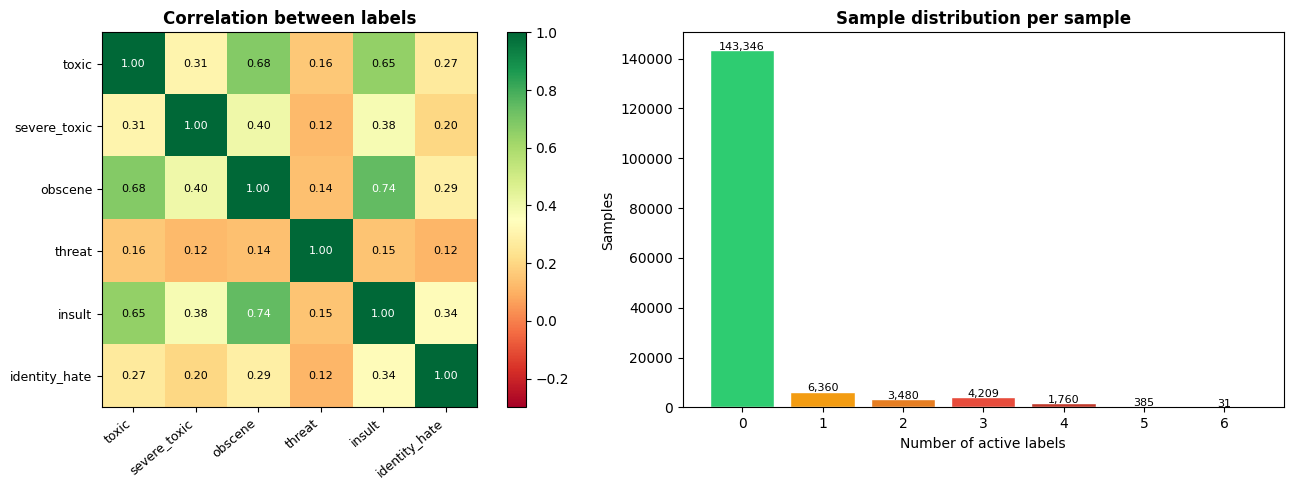


 Highly correlated labels:
   toxic           ↔ obscene        : 0.677
   toxic           ↔ insult         : 0.648
   obscene         ↔ insult         : 0.741


In [31]:
### Correlation between labels

corr_matrix = df_raw[label_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de correlación
im = axes[0].imshow(corr_matrix.values, cmap='RdYlGn', vmin=-0.3, vmax=1.0)
axes[0].set_xticks(range(len(label_cols)))
axes[0].set_yticks(range(len(label_cols)))
axes[0].set_xticklabels(label_cols, rotation=40, ha='right', fontsize=9)
axes[0].set_yticklabels(label_cols, fontsize=9)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        axes[0].text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=8,
                     color='black' if corr_matrix.values[i,j] < 0.7 else 'white')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Correlation between labels', fontweight='bold')

# Número de etiquetas por muestra
df_raw['n_labels'] = df_raw[label_cols].sum(axis=1)
label_count_dist = df_raw['n_labels'].value_counts().sort_index()
axes[1].bar(label_count_dist.index, label_count_dist.values,
            color=['#2ecc71','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad','#2c3e50'],
            edgecolor='white')
axes[1].set_title('Sample distribution per sample', fontweight='bold')
axes[1].set_xlabel('Number of active labels')
axes[1].set_ylabel('Samples')
axes[1].set_xticks(label_count_dist.index)

for bar, v in zip(axes[1].patches, label_count_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n Highly correlated labels:')
for i in range(len(label_cols)):
    for j in range(i+1, len(label_cols)):
        val = corr_matrix.values[i, j]
        if val > 0.5:
            print(f'   {label_cols[i]:15s} ↔ {label_cols[j]:15s}: {val:.3f}')

## Model exploration

Now that we have explored the dataset, we are going to explore the results given by the model and their robustness

### Model results in the test set

In [34]:
combos = defaultdict(list)

for i, sample in tqdm.tqdm(enumerate(test_set)):
    labels = tuple(int(x) for x in sample["labels"].numpy())
    text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)

    result = predict_with_uncertainty(
        model=model,
        tokenizer=tokenizer,
        text=text,
        id2label=id2label,
        device=device,
        threshold=0.5,
        top_k=3,
    )

    # probs y stds por label
    probs = np.array([p for _, p, _ in result["all_scores"]])
    stds  = np.array([s for _, _, s in result["all_scores"]])

    pred_labels = (probs >= 0.5).astype(int)
    correct = np.array_equal(np.array(labels), pred_labels)

    # métrica global de incertidumbre
    uncertainty = float(stds.mean())

    combos[labels].append({
        "index": i,
        "text": text,
        "combo_true": labels,
        "combo_pred": tuple(pred_labels.tolist()),
        "correct": correct,
        "uncertainty": uncertainty,
        "probs": probs.tolist(),
        "stds": stds.tolist(),
    })

15958it [10:30, 25.30it/s]


#### F1 scores and accuracy per label

In [36]:
all_samples = []
for combo_list in combos.values():
    all_samples.extend(combo_list)

uncertainties = np.array([x['uncertainty'] for x in all_samples])
corrects      = np.array([x['correct']     for x in all_samples]).astype(int)

num_labels = len(all_samples[0]['probs'])
y_true = np.array([x['combo_true'] for x in all_samples])
y_pred = np.array([x['combo_pred'] for x in all_samples])

print(f'Test samples: {len(all_samples):,}')


Test samples: 15,958


Global exact-match accuracy: 0.9157

  Label           | Accuracy |       F1
  --------------------------------------
  toxic           |   0.9543 |   0.7075
  severe_toxic    |   0.9907 |   0.2437
  obscene         |   0.9749 |   0.7315
  threat          |   0.9977 |   0.0000
  insult          |   0.9688 |   0.5958
  identity_hate   |   0.9924 |   0.3086
  --------------------------------------
  F1-micro        |          |   0.6561
  F1-macro        |          |   0.4312


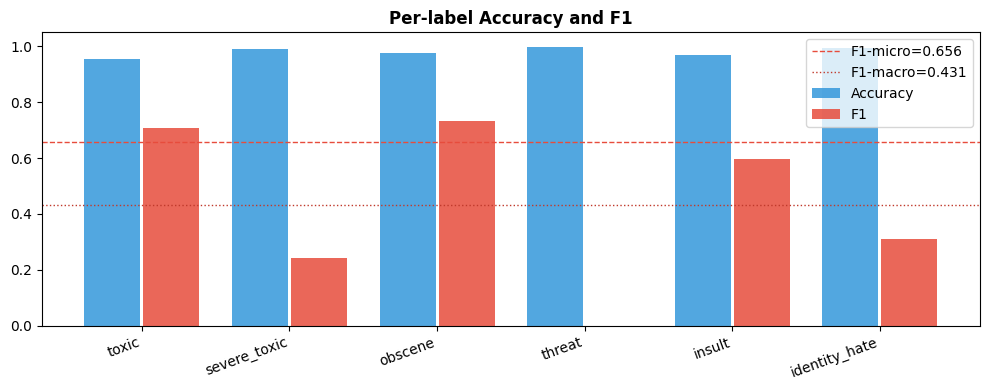

In [37]:
# Global exact-match accuracy
accuracy = corrects.mean()
print(f'Global exact-match accuracy: {accuracy:.4f}\n')

# Per-label accuracy and F1
label_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
accs = [(y_true[:,i] == y_pred[:,i]).mean() for i in range(num_labels)]
f1s  = [f1_score(y_true[:,i], y_pred[:,i], zero_division=0) for i in range(num_labels)]
f1_micro = f1_score(y_true, y_pred, average='micro',  zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro',  zero_division=0)

print(f'  {"Label":15s} | {"Accuracy":>8s} | {"F1":>8s}')
print('  ' + '-'*38)
for lbl, acc, f1 in zip(label_cols, accs, f1s):
    print(f'  {lbl:15s} | {acc:>8.4f} | {f1:>8.4f}')
print('  ' + '-'*38)
print(f'  {"F1-micro":15s} | {" ":>8s} | {f1_micro:>8.4f}')
print(f'  {"F1-macro":15s} | {" ":>8s} | {f1_macro:>8.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(num_labels)
ax.bar(x - 0.2, accs, 0.38, label='Accuracy', color='#3498db', alpha=0.85)
ax.bar(x + 0.2, f1s,  0.38, label='F1',       color='#e74c3c', alpha=0.85)
ax.axhline(f1_micro, linestyle='--', color='#e74c3c', linewidth=1, label=f'F1-micro={f1_micro:.3f}')
ax.axhline(f1_macro, linestyle=':',  color='#c0392b', linewidth=1, label=f'F1-macro={f1_macro:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Per-label Accuracy and F1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


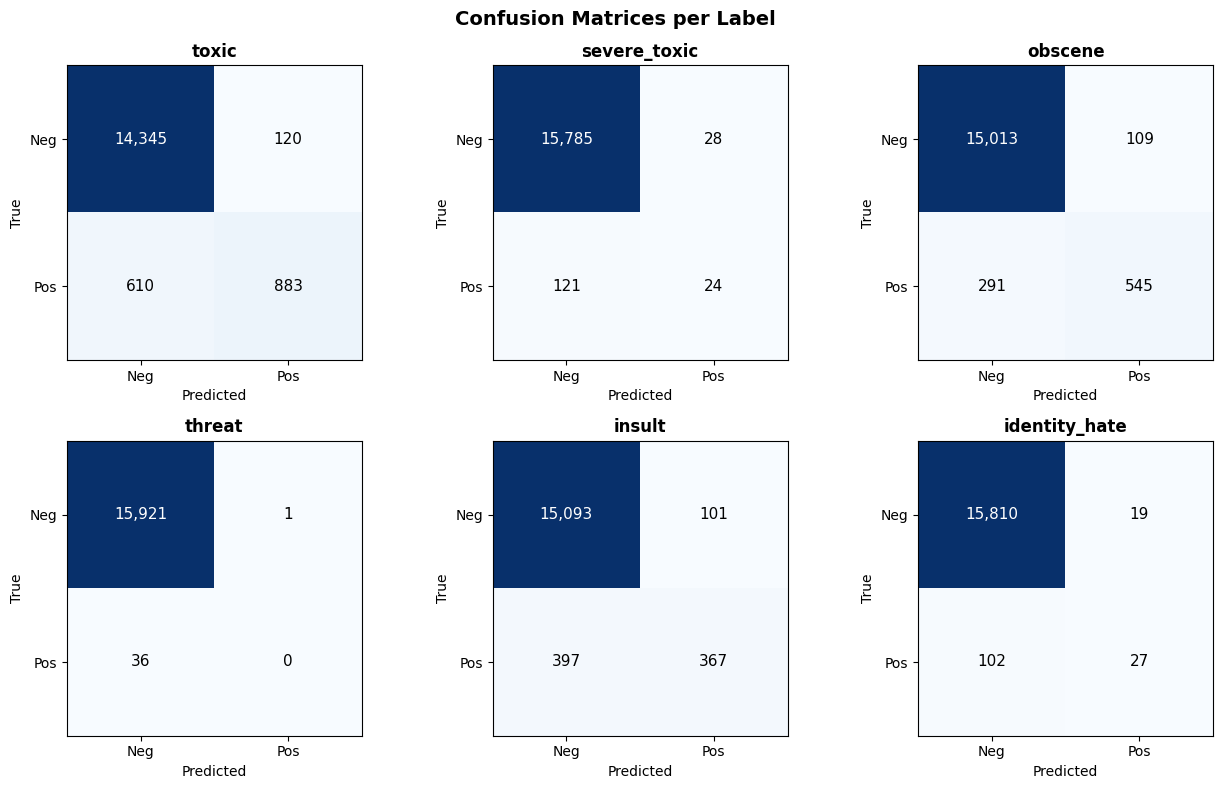

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (lbl, ax) in enumerate(zip(label_cols, axes)):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    im = ax.imshow(cm, cmap='Blues')
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm[r,c]:,}', ha='center', va='center',
                    color='white' if cm[r,c] > cm.max()/2 else 'black', fontsize=11)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Neg','Pos']); ax.set_yticklabels(['Neg','Pos'])

plt.suptitle('Confusion Matrices per Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Pearson r (uncertainty ↔ error): 0.635

   Bin |   Mean unc |   Accuracy
  --------------------------------
     0 |     0.0119 |     0.9994
     1 |     0.0159 |     0.9994
     2 |     0.0196 |     1.0000
     3 |     0.0241 |     0.9956
     4 |     0.0300 |     0.9981
     5 |     0.0385 |     0.9906
     6 |     0.0517 |     0.9875
     7 |     0.0771 |     0.9530
     8 |     0.1378 |     0.8182
     9 |     0.2681 |     0.4150

Top 20% most uncertain  → acc: 0.617
Top 20% most confident  → acc: 0.999


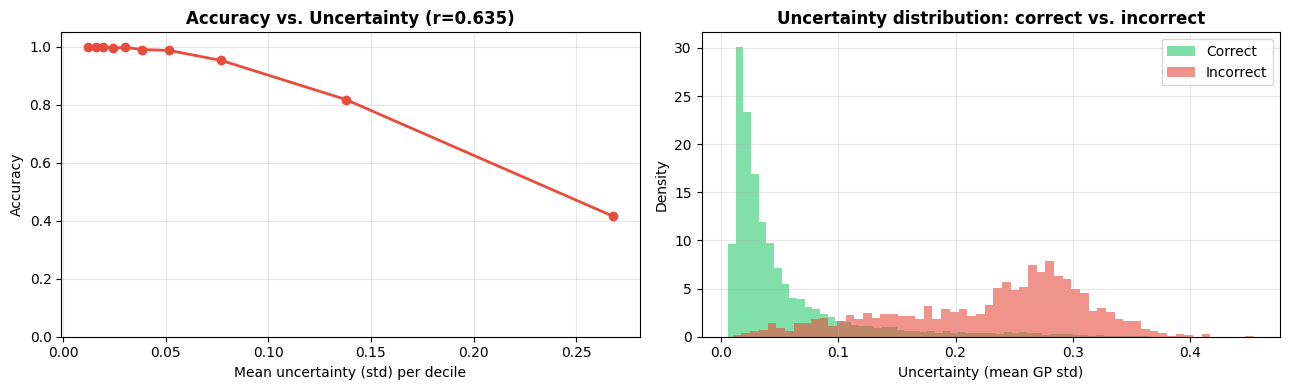

In [38]:
# Sort by uncertainty
order      = np.argsort(uncertainties)
unc_sorted = uncertainties[order]
corr_sorted= corrects[order]

# Pearson correlation uncertainty ↔ error
errors = 1 - corrects
r = np.corrcoef(uncertainties, errors)[0, 1]
print(f'Pearson r (uncertainty ↔ error): {r:.3f}')

# Accuracy by decile
n_bins = 10
bins   = np.array_split(np.arange(len(unc_sorted)), n_bins)
bin_unc  = [unc_sorted[b].mean() for b in bins]
bin_acc  = [corr_sorted[b].mean() for b in bins]

print(f'\n  {"Bin":>4s} | {"Mean unc":>10s} | {"Accuracy":>10s}')
print('  ' + '-'*32)
for i,(u,a) in enumerate(zip(bin_unc, bin_acc)):
    print(f'  {i:>4d} | {u:>10.4f} | {a:>10.4f}')

# Top-k
k = int(0.2 * len(all_samples))
acc_high = corrects[np.argsort(uncertainties)[-k:]].mean()
acc_low  = corrects[np.argsort(uncertainties)[:k]].mean()
print(f'\nTop 20% most uncertain  → acc: {acc_high:.3f}')
print(f'Top 20% most confident  → acc: {acc_low:.3f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(bin_unc, bin_acc, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Mean uncertainty (std) per decile')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Accuracy vs. Uncertainty (r={r:.3f})', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)

axes[1].hist(uncertainties[corrects==1], bins=60, alpha=0.6, label='Correct',   color='#2ecc71', density=True)
axes[1].hist(uncertainties[corrects==0], bins=60, alpha=0.6, label='Incorrect', color='#e74c3c', density=True)
axes[1].set_xlabel('Uncertainty (mean GP std)')
axes[1].set_ylabel('Density')
axes[1].set_title('Uncertainty distribution: correct vs. incorrect', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


#### Is the model more wrong when is uncertain?

In [40]:
all_samples = []
for combo_list in combos.values():
    all_samples.extend(combo_list)

uncertainties = np.array([x["uncertainty"] for x in all_samples])
corrects = np.array([x["correct"] for x in all_samples]).astype(int)

# ordenar por incertidumbre
order = np.argsort(uncertainties)
unc_sorted = uncertainties[order]
corr_sorted = corrects[order]

# dividir en bins (ej: 10)
n_bins = 10
bins = np.array_split(np.arange(len(unc_sorted)), n_bins)

print("\nAccuracy por nivel de incertidumbre:")
for i, b in enumerate(bins):
    acc = corr_sorted[b].mean()
    unc_mean = unc_sorted[b].mean()
    print(f"Bin {i}: unc={unc_mean:.3f} | acc={acc:.3f}")


Accuracy por nivel de incertidumbre:
Bin 0: unc=0.012 | acc=0.999
Bin 1: unc=0.016 | acc=0.999
Bin 2: unc=0.020 | acc=1.000
Bin 3: unc=0.024 | acc=0.996
Bin 4: unc=0.030 | acc=0.998
Bin 5: unc=0.039 | acc=0.991
Bin 6: unc=0.052 | acc=0.987
Bin 7: unc=0.077 | acc=0.953
Bin 8: unc=0.138 | acc=0.818
Bin 9: unc=0.268 | acc=0.415


## Model robustness

To study the model robustness, we will save the most uncertain predictions for each combinations of labels and try some common attacks to see if the model is robust againt them.

First, we will analyse the robustness on the sentences where the model is more uncertain

#### Keeping the two most uncertain per combo

In [58]:
top2_uncertain_per_combo = {}

for combo, samples in combos.items():
    top2 = sorted(samples, key=lambda x: x["uncertainty"], reverse=True)[:2]
    top2_uncertain_per_combo[combo] = top2

serializable = {
    str(combo): samples
    for combo, samples in top2_uncertain_per_combo.items()
}

with open("top2_uncertain_per_combo.json", "w", encoding="utf-8") as f:
    json.dump(serializable, f, ensure_ascii=False, indent=2)

#### See results

In [42]:
for combo in sorted(top2_uncertain_per_combo.keys()):
    print("\n==========================================")
    print("COMBO:", combo)

    samples = top2_uncertain_per_combo[combo]

    if not samples:
        print("No hay samples")
        continue

    for rank, s in enumerate(samples, 1):
        print(f"\n#{rank} más incierto — idx {s['index']}")
        print("TRUE:", s["combo_true"])
        print("PRED:", s["combo_pred"])
        print("CORRECT:", s["correct"])
        print(f"UNCERTAINTY(mean std): {s['uncertainty']:.4f}")
        print("STDS:", np.round(s["stds"], 4))
        print("PROBS:", np.round(s["probs"], 4))
        print("TEXT:", s["text"])


COMBO: (0, 0, 0, 0, 0, 0)

#1 más incierto — idx 13675
TRUE: (0, 0, 0, 0, 0, 0)
PRED: (1, 0, 0, 0, 0, 0)
CORRECT: False
UNCERTAINTY(mean std): 0.4124
STDS: [0.4682 0.3929 0.5    0.1907 0.4761 0.4467]
PROBS: [0.6753 0.1907 0.4937 0.0378 0.3471 0.2753]
TEXT: c o b a l t b l u e t o n y = eunuch

#2 más incierto — idx 2915
TRUE: (0, 0, 0, 0, 0, 0)
PRED: (1, 0, 0, 0, 0, 1)
CORRECT: False
UNCERTAINTY(mean std): 0.3653
STDS: [0.4452 0.2019 0.4714 0.1496 0.4549 0.4685]
PROBS: [0.7276 0.0426 0.3332 0.0229 0.2925 0.6746]
TEXT: racists i think every hick member of the national alliance should read guns, germs and steel. then, white supremacy would cease to exist. seriously.

COMBO: (0, 0, 0, 0, 0, 1)

#1 más incierto — idx 12148
TRUE: (0, 0, 0, 0, 0, 1)
PRED: (0, 0, 0, 0, 0, 0)
CORRECT: False
UNCERTAINTY(mean std): 0.2818
STDS: [0.495  0.0873 0.3518 0.0388 0.2867 0.4314]
PROBS: [0.4293 0.0077 0.1447 0.0015 0.0904 0.2472]
TEXT: it is obvius to, me, a black man, that orange is for da black gs, bl

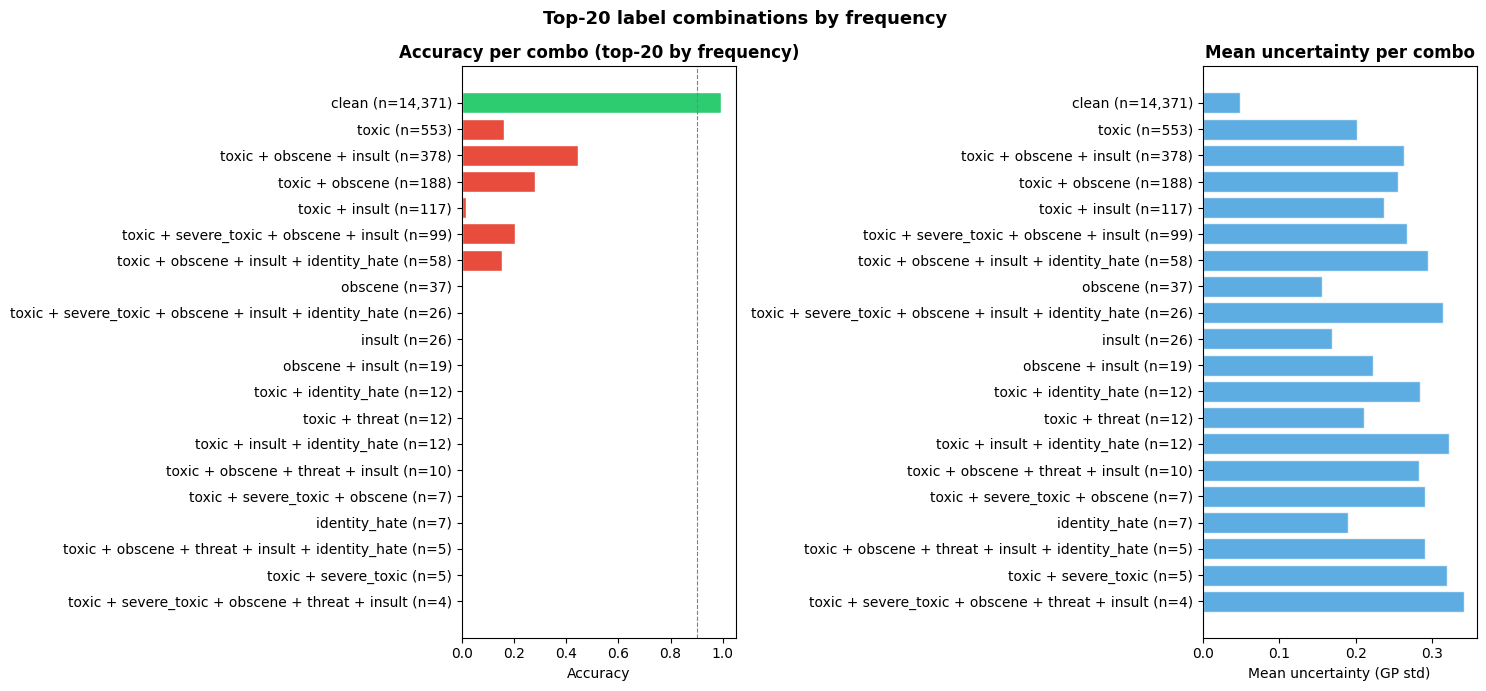

In [43]:
combo_stats = []
for combo, samples in combos.items():
    if not samples: continue
    combo_stats.append({
        'combo':   combo,
        'n':       len(samples),
        'acc':     np.mean([s['correct']     for s in samples]),
        'unc':     np.mean([s['uncertainty'] for s in samples]),
        'label':   ' + '.join(label_cols[i] for i,v in enumerate(combo) if v) or 'clean',
    })

combo_stats.sort(key=lambda x: -x['n'])
top_combos = combo_stats[:20]  # top-20 most frequent

labels_c = [f"{c['label']} (n={c['n']:,})" for c in top_combos]
accs_c   = [c['acc'] for c in top_combos]
uncs_c   = [c['unc'] for c in top_combos]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors_acc = ['#2ecc71' if a > 0.9 else '#f39c12' if a > 0.7 else '#e74c3c' for a in accs_c]
axes[0].barh(labels_c[::-1], accs_c[::-1], color=colors_acc[::-1], edgecolor='white')
axes[0].axvline(0.9, linestyle='--', color='gray', linewidth=0.8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy per combo (top-20 by frequency)', fontweight='bold')
axes[0].set_xlim(0, 1.05)

axes[1].barh(labels_c[::-1], uncs_c[::-1], color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Mean uncertainty (GP std)')
axes[1].set_title('Mean uncertainty per combo', fontweight='bold')

plt.suptitle('Top-20 label combinations by frequency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [47]:
def leet_speak(text):
    """Replace letters with visually similar digits (l33tspeak)."""
    return text.translate(str.maketrans('aeiost', '431057'))

def add_spaces(text):
    """Insert spaces between every character of long words."""
    return ' '.join(' '.join(w) if len(w) > 4 else w for w in text.split())

def unicode_homoglyphs(text):
    """Replace Latin letters with visually identical Cyrillic characters."""
    return text.translate(str.maketrans('aeoi', 'аеоі'))

def add_typos(text, rate=0.12, seed=42):
    """Randomly duplicate or drop characters."""
    rng, result = random.Random(seed), []
    for c in text:
        r = rng.random()
        if   r < rate/2:  pass
        elif r < rate:    result.extend([c, c])
        else:             result.append(c)
    return ''.join(result)

def punct_noise(text):
    """Intercalate dots between pairs of word characters."""
    return re.sub(r'(\w)(\w)', r'\1.\2', text)

def neutral_prefix(text):
    """Prepend an innocuous phrase to dilute toxicity signal."""
    return 'In my humble opinion, ' + text

TRANSFORMS = {
    'original':          lambda x: x,
    'leet_speak':        leet_speak,
    'add_spaces':        add_spaces,
    'unicode_homoglyphs':unicode_homoglyphs,
    'typos':             add_typos,
    'punct_noise':       punct_noise,
    'neutral_prefix':    neutral_prefix,
}
print('Perturbation functions:', list(TRANSFORMS.keys()))


Perturbation functions: ['original', 'leet_speak', 'add_spaces', 'unicode_homoglyphs', 'typos', 'punct_noise', 'neutral_prefix']


In [59]:
adv_corpus = []
for combo, samples in top2_uncertain_per_combo.items():
    for s in samples:
        adv_corpus.append({
            'text':        s['text'],
            'true_labels': s['combo_true'],
            'orig_preds':  s['combo_pred'],
            'orig_unc':    s['uncertainty'],
            'orig_correct':s['correct'],
            'combo':       combo,
            'combo_name':  ' + '.join(label_cols[i] for i,v in enumerate(combo) if v) or 'clean',
        })

print(f'Adversarial corpus: {len(adv_corpus)} samples')
print(f'  Covering {len(top2_uncertain_per_combo)} label combinations')
print(f'  Mean baseline uncertainty: {np.mean([s["orig_unc"] for s in adv_corpus]):.4f}')
print(f'  Baseline accuracy on these samples: {np.mean([s["orig_correct"] for s in adv_corpus]):.4f}')


Adversarial corpus: 51 samples
  Covering 29 label combinations
  Mean baseline uncertainty: 0.3403
  Baseline accuracy on these samples: 0.0588


In [53]:
adv_results = []  # one entry per corpus sample

for entry in tqdm.tqdm(adv_corpus):
    row = {
        'combo':      entry['combo'],
        'combo_name': entry['combo_name'],
        'text':       entry['text'],
        'true_labels':entry['true_labels'],
        'orig_preds': entry['orig_preds'],
        'orig_unc':   entry['orig_unc'],
        'orig_correct':entry['orig_correct'],
        'variants':   [],
    }

    for t_name, t_fn in TRANSFORMS.items():
        if t_name == 'original':
            # We already have the original prediction — reuse it
            row['variants'].append({
                'transform':   'original',
                'text':        entry['text'],
                'preds':       list(entry['orig_preds']),
                'uncertainty': entry['orig_unc'],
                'flipped':     False,
                'correct':     entry['orig_correct'],
            })
            continue

        perturbed = t_fn(entry['text'])
        result    = predict_with_uncertainty(
            model=model, tokenizer=tokenizer, text=perturbed,
            id2label=id2label, device=device, threshold=0.5, top_k=3)

        probs = np.array([p for _,p,_ in result['all_scores']])
        stds  = np.array([s for _,_,s in result['all_scores']])
        preds = (probs >= 0.5).astype(int).tolist()
        unc   = float(stds.mean())

        row['variants'].append({
            'transform':   t_name,
            'text':        perturbed,
            'probs':       probs.tolist(),
            'stds':        stds.tolist(),
            'preds':       preds,
            'uncertainty': unc,
            'flipped':     preds != list(entry['orig_preds']),
            'correct':     bool(np.array_equal(preds, list(entry['true_labels']))),
            'unc_delta':   unc - entry['orig_unc'],  # +ve = more uncertain after perturbation
        })

    adv_results.append(row)

print(f'Done. {len(adv_results)} samples evaluated.')


100%|██████████| 51/51 [00:12<00:00,  3.95it/s]

Done. 51 samples evaluated.


  Transform                 |  Flip rate |  Mean Δunc |   Accuracy
  ----------------------------------------------------------------
  leet_speak                |     78.4%  |    -0.0484 |     0.0392
  add_spaces                |     64.7%  |    +0.0602 |     0.0588
  unicode_homoglyphs        |     80.4%  |    -0.1221 |     0.0392
  typos                     |     70.6%  |    -0.0477 |     0.0392
  punct_noise               |     78.4%  |    +0.0141 |     0.0588
  neutral_prefix            |     11.8%  |    -0.0193 |     0.0784


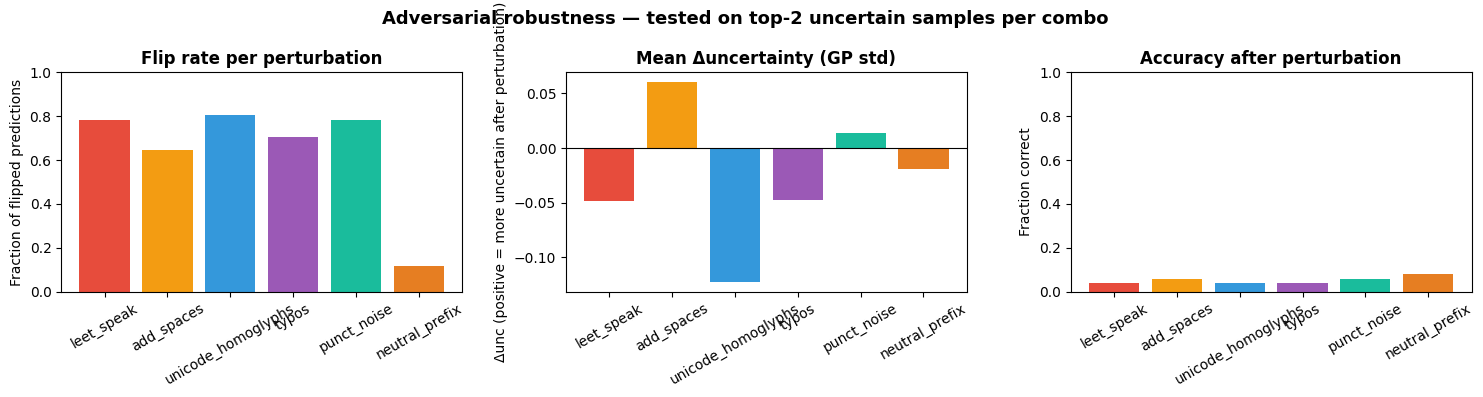

In [54]:
transform_names = [t for t in TRANSFORMS.keys() if t != 'original']

summary = {}
for t_name in transform_names:
    flips, delta_uncs, accs = [], [], []
    for row in adv_results:
        v = next(x for x in row['variants'] if x['transform'] == t_name)
        flips.append(int(v['flipped']))
        delta_uncs.append(v['unc_delta'])
        accs.append(int(v['correct']))
    summary[t_name] = {
        'flip_rate': np.mean(flips),
        'mean_delta_unc': np.mean(delta_uncs),
        'accuracy': np.mean(accs),
    }

print(f'  {"Transform":25s} | {"Flip rate":>10s} | {"Mean Δunc":>10s} | {"Accuracy":>10s}')
print('  ' + '-'*64)
for t, s in summary.items():
    print(f'  {t:25s} | {s["flip_rate"]:>9.1%}  | {s["mean_delta_unc"]:>+10.4f} | {s["accuracy"]:>10.4f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_labels = list(summary.keys())
colors   = ['#e74c3c','#f39c12','#3498db','#9b59b6','#1abc9c','#e67e22']

axes[0].bar(t_labels, [summary[t]['flip_rate']      for t in t_labels], color=colors)
axes[0].set_title('Flip rate per perturbation', fontweight='bold')
axes[0].set_ylabel('Fraction of flipped predictions')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(t_labels, [summary[t]['mean_delta_unc'] for t in t_labels], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean Δuncertainty (GP std)', fontweight='bold')
axes[1].set_ylabel('Δunc (positive = more uncertain after perturbation)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(t_labels, [summary[t]['accuracy']       for t in t_labels], color=colors)
axes[2].set_title('Accuracy after perturbation', fontweight='bold')
axes[2].set_ylabel('Fraction correct')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Adversarial robustness — tested on top-2 uncertain samples per combo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Flipped predictions  — mean Δunc: -0.0385  (n=196)
Stable  predictions  — mean Δunc: -0.0071  (n=110)

Welch t-test: t=-3.314, p=0.0010
→ GP uncertainty is a statistically significant predictor of prediction flips.


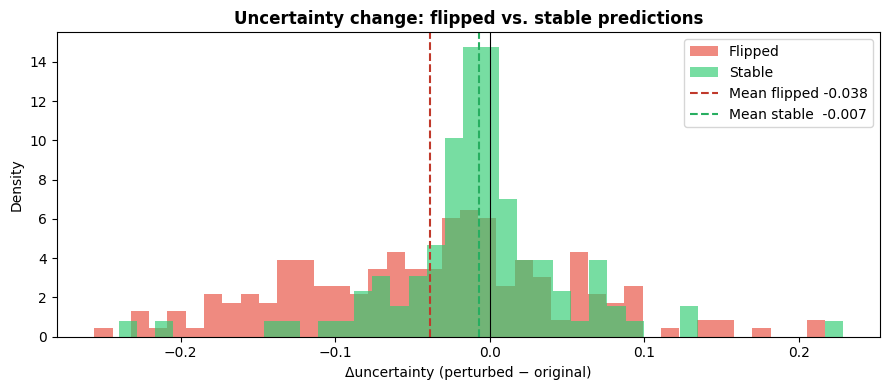

In [55]:
delta_flipped   = []
delta_stable    = []

for row in adv_results:
    for v in row['variants']:
        if v['transform'] == 'original': continue
        if v['flipped']:  delta_flipped.append(v['unc_delta'])
        else:             delta_stable.append(v['unc_delta'])

print(f'Flipped predictions  — mean Δunc: {np.mean(delta_flipped):+.4f}  (n={len(delta_flipped)})')
print(f'Stable  predictions  — mean Δunc: {np.mean(delta_stable):+.4f}  (n={len(delta_stable)})')

from scipy import stats
t_stat, p_val = stats.ttest_ind(delta_flipped, delta_stable)
print(f'\nWelch t-test: t={t_stat:.3f}, p={p_val:.4f}')
print('→ GP uncertainty is a statistically significant predictor of prediction flips.' if p_val < 0.05
      else '→ No statistically significant difference detected.')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(delta_flipped, bins=40, alpha=0.65, label='Flipped', color='#e74c3c', density=True)
ax.hist(delta_stable,  bins=40, alpha=0.65, label='Stable',  color='#2ecc71', density=True)
ax.axvline(np.mean(delta_flipped), color='#c0392b', linestyle='--', linewidth=1.5, label=f'Mean flipped {np.mean(delta_flipped):+.3f}')
ax.axvline(np.mean(delta_stable),  color='#27ae60', linestyle='--', linewidth=1.5, label=f'Mean stable  {np.mean(delta_stable):+.3f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δuncertainty (perturbed − original)')
ax.set_ylabel('Density')
ax.set_title('Uncertainty change: flipped vs. stable predictions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


In [56]:
for t_name in transform_names:
    flipped_cases = [
        row for row in adv_results
        if next(x for x in row['variants'] if x['transform']==t_name)['flipped']
    ]
    if not flipped_cases:
        print(f'\n[{t_name}] No flips.')
        continue
    print(f'\n' + '='*60)
    print(f'Transform: {t_name}  ({len(flipped_cases)} flips / {len(adv_results)} samples)')
    print('='*60)
    for row in flipped_cases:
        v = next(x for x in row['variants'] if x['transform']==t_name)
        print(f'\n  Combo      : {row["combo"]}  [{row["combo_name"]}]')
        print(f'  True labels: {list(row["true_labels"])}')
        print(f'  Orig pred  : {list(row["orig_preds"])}  (correct={row["orig_correct"]})')
        print(f'  New  pred  : {v["preds"]}')
        print(f'  Orig unc   : {row["orig_unc"]:.4f}  →  New unc: {v["uncertainty"]:.4f}  (Δ={v["unc_delta"]:+.4f})')
        print(f'  Original   : {row["text"][:100]}')
        print(f'  Perturbed  : {v["text"][:100]}')



Transform: leet_speak  (40 flips / 51 samples)

  Combo      : (0, 0, 0, 0, 0, 0)  [clean]
  True labels: [0, 0, 0, 0, 0, 0]
  Orig pred  : [1, 0, 0, 0, 0, 0]  (correct=False)
  New  pred  : [1, 0, 1, 0, 0, 0]
  Orig unc   : 0.4124  →  New unc: 0.3884  (Δ=-0.0241)
  Original   : c o b a l t b l u e t o n y = eunuch
  Perturbed  : c 0 b 4 l 7 b l u 3 7 0 n y = 3unuch

  Combo      : (0, 0, 0, 0, 0, 0)  [clean]
  True labels: [0, 0, 0, 0, 0, 0]
  Orig pred  : [1, 0, 0, 0, 0, 1]  (correct=False)
  New  pred  : [0, 0, 0, 0, 0, 0]
  Orig unc   : 0.3653  →  New unc: 0.2481  (Δ=-0.1172)
  Original   : racists i think every hick member of the national alliance should read guns, germs and steel. then, 
  Perturbed  : r4c1575 1 7h1nk 3v3ry h1ck m3mb3r 0f 7h3 n4710n4l 4ll14nc3 5h0uld r34d gun5, g3rm5 4nd 5733l. 7h3n, 

  Combo      : (1, 1, 1, 0, 1, 0)  [toxic + severe_toxic + obscene + insult]
  True labels: [1, 1, 1, 0, 1, 0]
  Orig pred  : [1, 0, 1, 0, 0, 0]  (correct=False)
  New  pred  : [0

#### Keeping the most certain combos

In [60]:
# Build the low-uncertainty corpus (2 most confident per combo)
low_unc_corpus = []

for combo, samples in combos.items():
    bottom2 = sorted(samples, key=lambda x: x['uncertainty'])[:2]
    for s in bottom2:
        low_unc_corpus.append({
            'text':        s['text'],
            'true_labels': s['combo_true'],
            'orig_preds':  s['combo_pred'],
            'orig_unc':    s['uncertainty'],
            'orig_correct':s['correct'],
            'combo':       combo,
            'combo_name':  ' + '.join(label_cols[i] for i,v in enumerate(combo) if v) or 'clean',
        })

print(f'Low-uncertainty corpus: {len(low_unc_corpus)} samples')
print(f'  Covering {len(combos)} label combinations')
print(f'  Mean baseline uncertainty: {np.mean([s["orig_unc"] for s in low_unc_corpus]):.4f}')
print(f'  Baseline accuracy on these samples: {np.mean([s["orig_correct"] for s in low_unc_corpus]):.4f}')

Low-uncertainty corpus: 51 samples
  Covering 29 label combinations
  Mean baseline uncertainty: 0.1680
  Baseline accuracy on these samples: 0.0392


100%|██████████| 51/51 [00:11<00:00,  4.36it/s]



Transform                 | High-unc flip | Low-unc flip | High-unc Δunc | Low-unc Δunc
------------------------------------------------------------------------------------
leet_speak                |        78.4%  |       45.1%  |       -0.0484 |      +0.1020
add_spaces                |        64.7%  |       49.0%  |       +0.0602 |      +0.1851
unicode_homoglyphs        |        80.4%  |       39.2%  |       -0.1221 |      +0.0339
typos                     |        70.6%  |       31.4%  |       -0.0477 |      +0.0558
punct_noise               |        78.4%  |       74.5%  |       +0.0141 |      +0.1770
neutral_prefix            |        11.8%  |        5.9%  |       -0.0193 |      -0.0010


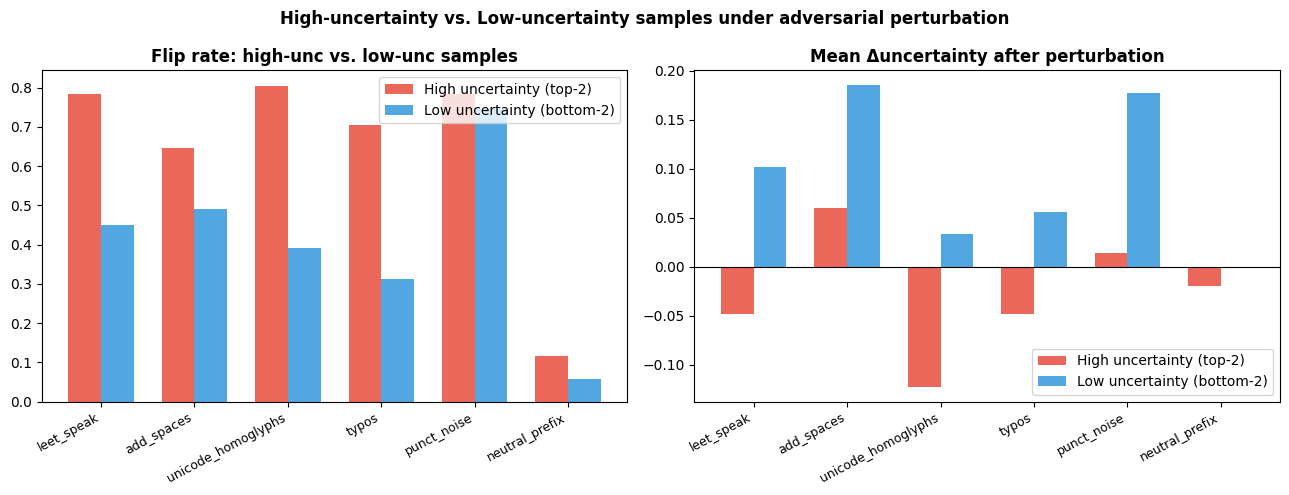

In [61]:
# Evaluate perturbations on the low-uncertainty corpus
low_unc_results = []

for entry in tqdm.tqdm(low_unc_corpus):
    row = {**entry, 'variants': []}
    for t_name, t_fn in TRANSFORMS.items():
        if t_name == 'original':
            row['variants'].append({
                'transform': 'original', 'text': entry['text'],
                'preds': list(entry['orig_preds']), 'uncertainty': entry['orig_unc'],
                'flipped': False, 'correct': entry['orig_correct'], 'unc_delta': 0.0,
            })
            continue
        perturbed = t_fn(entry['text'])
        result    = predict_with_uncertainty(
            model=model, tokenizer=tokenizer, text=perturbed,
            id2label=id2label, device=device, threshold=0.5, top_k=3)
        probs = np.array([p for _,p,_ in result['all_scores']])
        stds  = np.array([s for _,_,s in result['all_scores']])
        preds = (probs >= 0.5).astype(int).tolist()
        unc   = float(stds.mean())
        row['variants'].append({
            'transform': t_name, 'text': perturbed,
            'probs': probs.tolist(), 'stds': stds.tolist(), 'preds': preds,
            'uncertainty': unc, 'flipped': preds != list(entry['orig_preds']),
            'correct': bool(np.array_equal(preds, list(entry['true_labels']))),
            'unc_delta': unc - entry['orig_unc'],
        })
    low_unc_results.append(row)

# ── Comparative summary ──────────────────────────────────────────────────────
transform_names = [t for t in TRANSFORMS if t != 'original']

print(f'\n{"Transform":25s} | {"High-unc flip":>13s} | {"Low-unc flip":>12s} | {"High-unc Δunc":>13s} | {"Low-unc Δunc":>12s}')
print('-' * 84)

for t_name in transform_names:
    def stats(results):
        flips, deltas = [], []
        for row in results:
            v = next(x for x in row['variants'] if x['transform'] == t_name)
            flips.append(int(v['flipped']))
            deltas.append(v['unc_delta'])
        return np.mean(flips), np.mean(deltas)

    hf, hd = stats(adv_results)
    lf, ld = stats(low_unc_results)
    print(f'{t_name:25s} | {hf:>12.1%}  | {lf:>11.1%}  | {hd:>+13.4f} | {ld:>+12.4f}')

# ── Visual comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(transform_names))
w = 0.35

for ax, metric, title, fmt in [
    (axes[0], 'flip_rate',      'Flip rate: high-unc vs. low-unc samples',      '{:.1%}'),
    (axes[1], 'mean_delta_unc', 'Mean Δuncertainty after perturbation',          '{:+.4f}'),
]:
    high_vals, low_vals = [], []
    for t in transform_names:
        def get(results, key):
            vals = []
            for row in results:
                v = next(x for x in row['variants'] if x['transform'] == t)
                vals.append(int(v['flipped']) if key == 'flip_rate' else v['unc_delta'])
            return np.mean(vals)
        high_vals.append(get(adv_results,     metric))
        low_vals.append( get(low_unc_results, metric))

    ax.bar(x - w/2, high_vals, w, label='High uncertainty (top-2)', color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, low_vals,  w, label='Low uncertainty (bottom-2)', color='#3498db', alpha=0.85)
    if metric == 'mean_delta_unc':
        ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(transform_names, rotation=28, ha='right', fontsize=9)
    ax.legend()

plt.suptitle('High-uncertainty vs. Low-uncertainty samples under adversarial perturbation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()